In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import KShape
'''#Run this to regenerate the .npy files for the data
df = pd.read_parquet("data/RMDC26_Beginner_Tier_test.parquet")
print(df.columns)
print(df.shape)

event_names = [f"RMDC26_{i:06d}" for i in range(1, 189)]

# event names are from RMDC26_000001 to RMDC26_000188
# filters are ['F087', 'F146', 'F213']

def makeFliterDataMatrix(filter, df):
  res = []
  filter_name = filter
  for event_id in event_names:
    res.append(df.loc[(df["name"] == event_id) & (df["filt"] == filter_name), ["mag","mag_err","bjd"]].sort_values("bjd").to_numpy().T)
  return np.array(res)

F087 = makeFliterDataMatrix("F087", df)
print(F087.shape)
F146 = makeFliterDataMatrix("F146", df)
print(F146.shape)
F213 = makeFliterDataMatrix("F213", df)
print(F146.shape)

np.save("data/F087.npy", F087)
np.save("data/F146.npy", F146)
np.save("data/F213.npy", F213)'''

F087 = np.load("data/F087.npy")
F146 = np.load("data/F146.npy")
F213 = np.load("data/F213.npy")

/Users/agastya/miniconda3/envs/roman/lib/python3.13/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


Index(['name', 'l_deg', 'b_deg', 'ra_deg', 'dec_deg', 'bjd', 'filt', 'mag',
       'mag_err', 'extinction', 'obs_x', 'obs_y', 'obs_z', 'saturation_flag'],
      dtype='str')
(9230048, 14)
(188, 3, 1445)
(188, 3, 46208)
(188, 3, 46208)


In [24]:
# Now we have three numpy matrices for each filter.
# They have dims 188 x 3 x c
# 188 events, 3 features saved for each event (mag, mag err, bjd time), and then c raw channels

F087_mags = F087[:,0,:].reshape(F087.shape[0],F087.shape[2],1)
print(F087_mags.shape)

n_clusters = 10

ks = KShape(n_clusters=n_clusters, random_state=0)

labels = ks.fit_predict(F087_mags)

(188, 1445, 1)


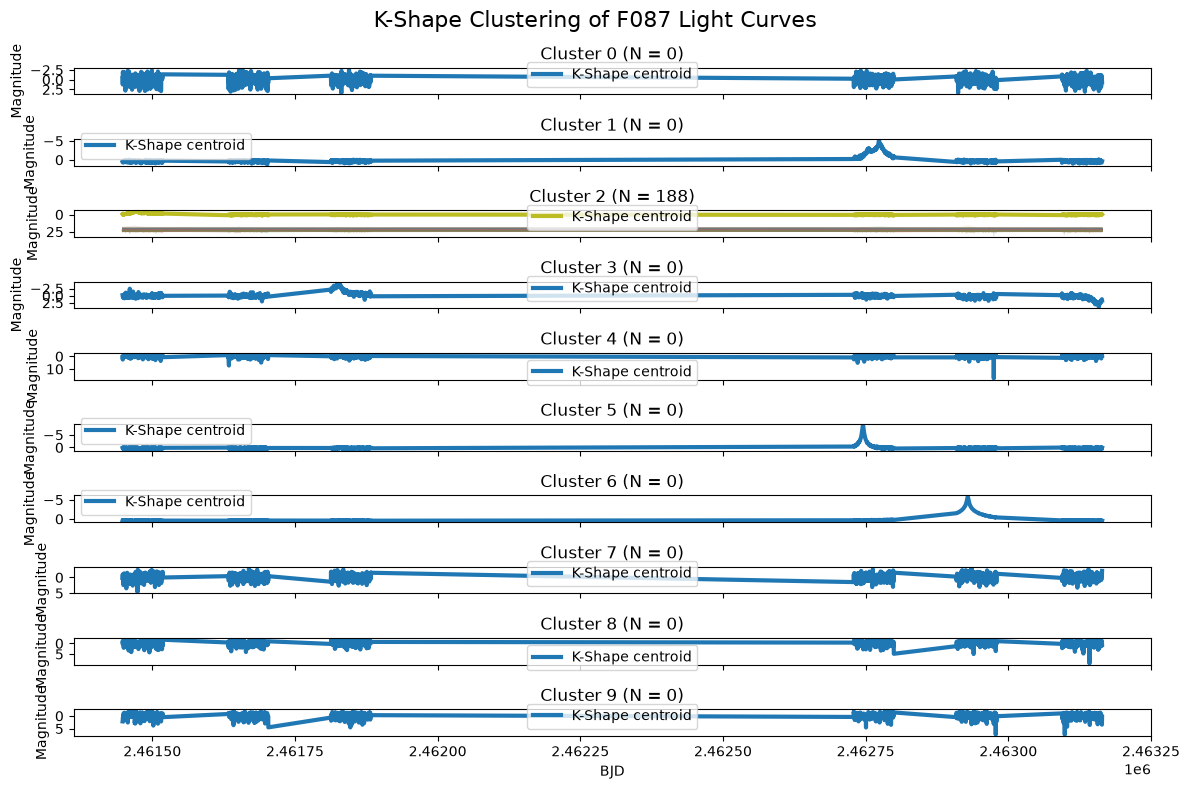

In [25]:
# Shared time axis
bjd = F087[0, 2, :]

fig, axes = plt.subplots(
    n_clusters,
    1,
    figsize=(12, 8),
    sharex=True
)

for cluster in range(n_clusters):

    ax = axes[cluster]

    cluster_data = F087_mags[labels == cluster, :, 0]

    # Individual light curves
    if len(cluster_data) > 0:
        ax.plot(
            bjd,
            cluster_data.T,
            alpha=0.15,
            linewidth=0.8
        )

    # K-Shape centroid
    centroid = ks.cluster_centers_[cluster, :, 0]

    ax.plot(
        bjd,
        centroid,
        linewidth=3,
        label="K-Shape centroid"
    )

    ax.set_ylabel("Magnitude")
    ax.set_title(
        f"Cluster {cluster} (N = {len(cluster_data)})"
    )
    ax.invert_yaxis()
    ax.legend()

axes[-1].set_xlabel("BJD")

fig.suptitle(
    "K-Shape Clustering of F087 Light Curves",
    fontsize=16
)

plt.tight_layout()
plt.show()